In [159]:
import pandas as pd
import bs4 as bs
import seaborn as sns
import matplotlib.pyplot as plt

import requests as rq


In [172]:
with open("Consumer Price Index Data from 1913 to 2026.html", "r", encoding="utf-8") as file:
    data = file.read()

soup = bs.BeautifulSoup(data,"html.parser")

table = soup.find("table")

rows = table.tbody.find_all("tr")

years = []
crips = []

for row in rows:
    year = row.find_all("td")[0].get_text()
    if year.isdigit() and int(year) < 2017:
        years.append(int(year))
        crips.append(row.find_all("td")[13].get_text())

cpi_table = pd.DataFrame({
    "year": years,
    "cpi": crips
})

cpi_table

,year,cpi
0,1913,9.9
1,1914,10.0
2,1915,10.1
3,1916,10.9
4,1917,12.8
...,...,...
99,2012,229.594
100,2013,232.957
101,2014,236.736
102,2015,237.017


In [ ]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    real_value = (nominal_amt * new_cpi) / old_cpi
    return real_value

In [174]:
data = pd.read_csv("data_sets/Dataset1.csv")

In [182]:
real_domestic_gross = []
real_budget_values = []
cpi_2016 = float(cpi_table[cpi_table["year"] == 2016]["cpi"])

for index, row in data.iterrows():
    gross = row["gross"]
    budget = row["budget"]
    year = row["title_year"]
    cpi = (cpi_table[[cpi_table["year"] == int(year)]])
    print(cpi)

TypeError: float() argument must be a string or a real number, not 'Series'

In [128]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   color                       5025 non-null   str    
 1   Director_Name               4872 non-null   str    
 2   num_Critic_for_reviews      4927 non-null   float64
 3   duration                    4959 non-null   float64
 4   director_Facebook_likes     4872 non-null   float64
 5   actor_3_Facebook_likes      4953 non-null   float64
 6   actor_2_name                4963 non-null   str    
 7   Actor_1_Facebook_likes      4968 non-null   float64
 8   gross                       4104 non-null   float64
 9   genres                      4974 non-null   str    
 10  actor_1_name                4968 non-null   str    
 11  movie_Title                 4974 non-null   str    
 12  num_voted_users             4974 non-null   float64
 13   cast_total_facebook_likes  4974 non-null   

In [129]:
data.duplicated().sum()

np.int64(45)

In [130]:
data.drop_duplicates()

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000;
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0;
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000;
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000;
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0;
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84;
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000;
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16;
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660;


In [131]:
data.isna().sum()

color                          18
Director_Name                 171
num_Critic_for_reviews        116
duration                       84
director_Facebook_likes       171
actor_3_Facebook_likes         90
actor_2_name                   80
Actor_1_Facebook_likes         75
gross                         939
genres                         69
actor_1_name                   75
movie_Title                    69
num_voted_users                69
 cast_total_facebook_likes     69
actor_3_name                   90
facenumber_in_poster           82
plot_keywords                 216
movie_imdb_link                69
num_user_for_reviews           87
language                       82
country                        72
content_rating                366
budget                        549
title_year                    174
actor_2_facebook_likes         80
imdb_score                     69
aspect_ratio                  389
movie_facebook_likes;          69
dtype: int64

In [132]:
str_columns = data.select_dtypes(include='string').columns
str_columns

Index(['color', 'Director_Name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_Title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link',
       'language', 'country', 'content_rating', 'movie_facebook_likes;'],
      dtype='str')

In [133]:
categorial_columns = str_columns.drop("movie_facebook_likes;")

data.rename({"movie_facebook_likes;":"movie_facebook_likes"}, inplace = True, axis=1)
data["movie_facebook_likes"] = data["movie_facebook_likes"].str.replace(";", "")
data["movie_facebook_likes"] = data["movie_facebook_likes"].astype(float)

categorial_columns

Index(['color', 'Director_Name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_Title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link',
       'language', 'country', 'content_rating'],
      dtype='str')

In [134]:
for column in categorial_columns:
    data[column] = data[column].fillna(data[column].mode()[0])

numeric_columns = data.select_dtypes(include="number").columns
for column in numeric_columns:
    data[column] = data[column].fillna(data[column].median())

In [135]:
data.isna().sum()

color                         0
Director_Name                 0
num_Critic_for_reviews        0
duration                      0
director_Facebook_likes       0
actor_3_Facebook_likes        0
actor_2_name                  0
Actor_1_Facebook_likes        0
gross                         0
genres                        0
actor_1_name                  0
movie_Title                   0
num_voted_users               0
 cast_total_facebook_likes    0
actor_3_name                  0
facenumber_in_poster          0
plot_keywords                 0
movie_imdb_link               0
num_user_for_reviews          0
language                      0
country                       0
content_rating                0
budget                        0
title_year                    0
actor_2_facebook_likes        0
imdb_score                    0
aspect_ratio                  0
movie_facebook_likes          0
dtype: int64

In [136]:
data.describe()

,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,5043.000000,5043.000000,5043.000000,5043.000000,5043.00000,5.043000e+03,5.043000e+03,5043.000000,5043.000000,5043.000000,5.043000e+03,5043.000000,5043.000000,5043.000000,5043.000000,5043.000000
mean,139.869720,107.124132,669.456871,642.868531,6490.47214,4.433833e+07,8.315077e+04,9638.549177,1.366647,271.573468,3.781071e+07,2002.574658,1643.190561,6.441959,2.233119,7470.780984
std,120.535511,24.774814,2776.189759,1658.130651,14979.85268,6.247029e+07,1.378445e+05,18119.377709,2.001342,375.774914,1.958590e+08,12.225589,4025.851655,1.116440,1.338851,19308.507567
min,1.000000,7.000000,0.000000,0.000000,0.00000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,51.000000,93.000000,8.000000,139.500000,625.00000,9.116578e+06,8.972500e+03,1442.000000,0.000000,67.000000,7.500000e+06,1999.000000,290.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,372.000000,989.00000,2.559138e+07,3.450400e+04,3097.500000,1.000000,157.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,165.500000
75%,192.000000,117.000000,188.000000,633.000000,11000.00000,5.089081e+07,9.444550e+04,13629.500000,2.000000,322.000000,4.000000e+07,2010.000000,912.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.00000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


array([[<Axes: title={'center': 'num_Critic_for_reviews'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'director_Facebook_likes'}>,
        <Axes: title={'center': 'actor_3_Facebook_likes'}>],
       [<Axes: title={'center': 'Actor_1_Facebook_likes'}>,
        <Axes: title={'center': 'gross'}>,
        <Axes: title={'center': 'num_voted_users'}>,
        <Axes: title={'center': ' cast_total_facebook_likes'}>],
       [<Axes: title={'center': 'facenumber_in_poster'}>,
        <Axes: title={'center': 'num_user_for_reviews'}>,
        <Axes: title={'center': 'budget'}>,
        <Axes: title={'center': 'title_year'}>],
       [<Axes: title={'center': 'actor_2_facebook_likes'}>,
        <Axes: title={'center': 'imdb_score'}>,
        <Axes: title={'center': 'aspect_ratio'}>,
        <Axes: title={'center': 'movie_facebook_likes'}>]], dtype=object)

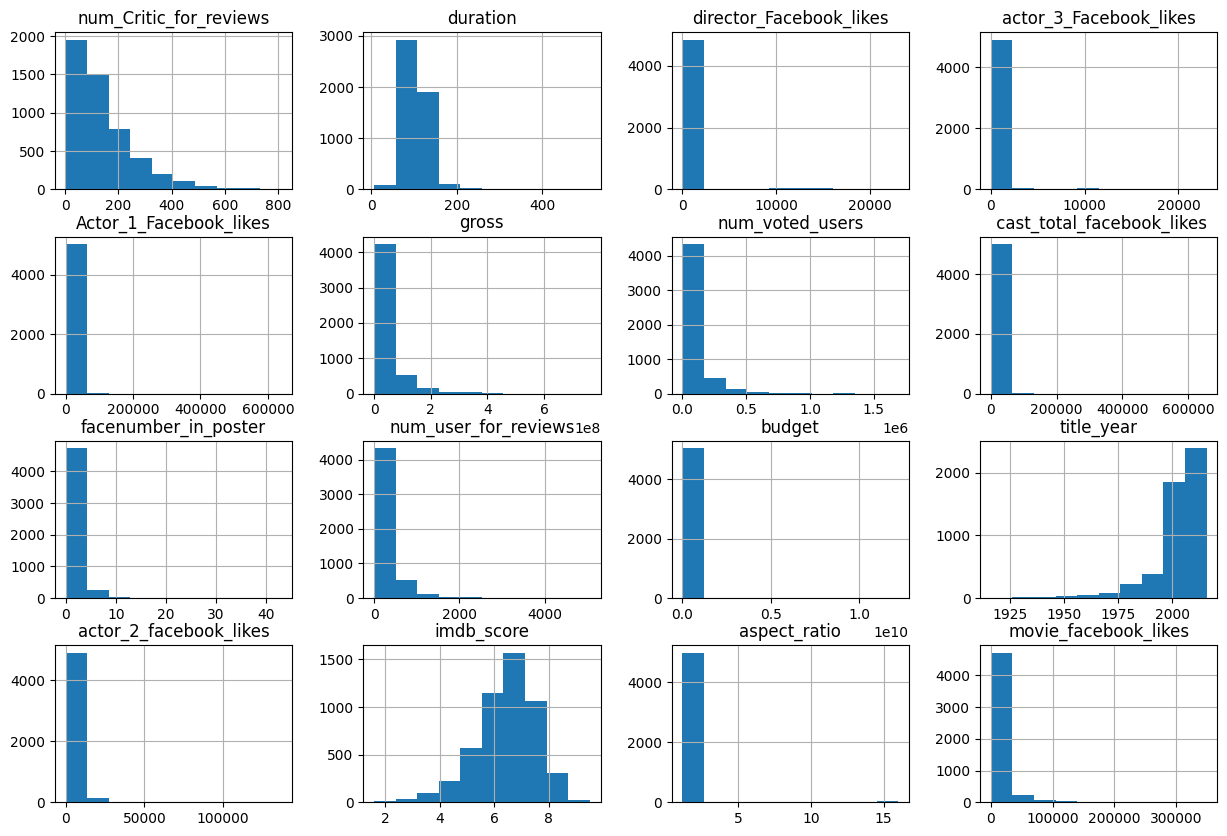

In [137]:
data.hist(figsize=(15, 10))

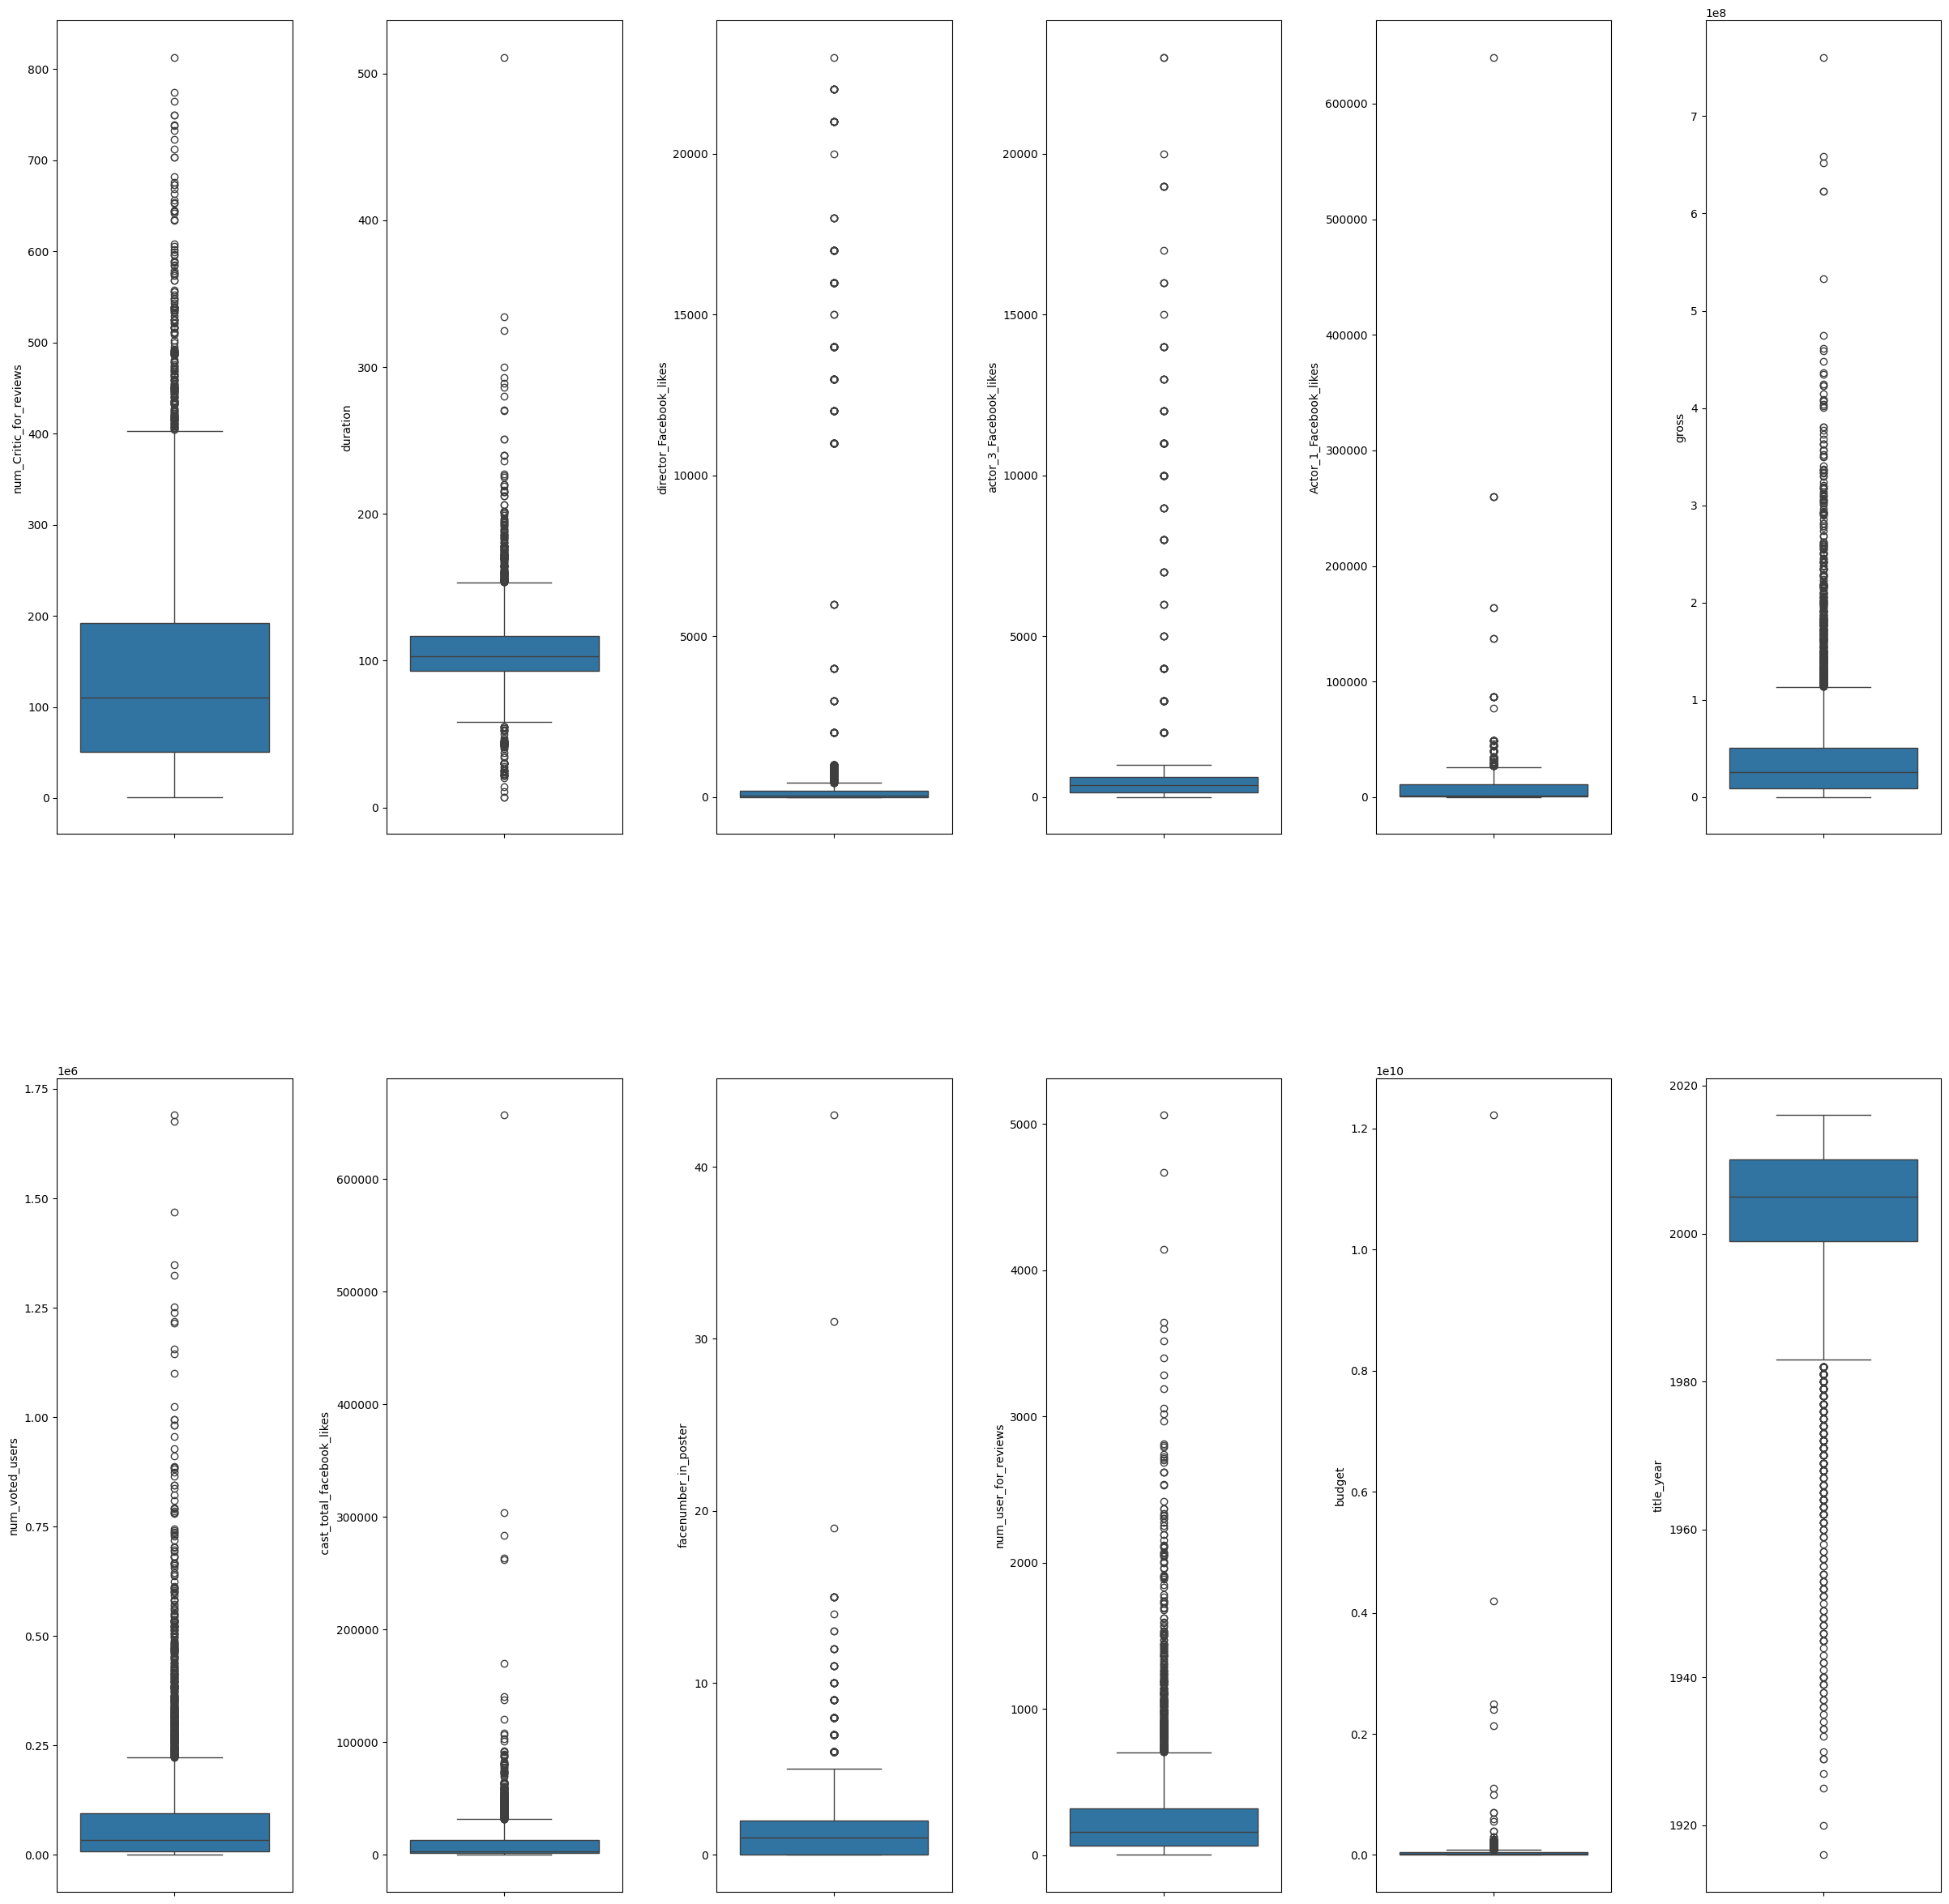

In [157]:
fig, axs = plt.subplots(2, 6, figsize=(30, 30))
plt.subplots_adjust(wspace=0.4, hspace=0.3)
ax_flatten = axs.flatten()
for i in range(len(ax_flatten)):
    sns.boxplot(data, y = data[numeric_columns[i]], ax = ax_flatten[i])

In [152]:
numeric_data = data[numeric_columns]

q1 = numeric_data.quantile(0.25)
q3 = numeric_data.quantile(0.75)


IQR = q3 - q1

data_filtered = numeric_data[~((numeric_data < (q1 - 1.5 * IQR)) |(numeric_data > (q3 + 1.5 * IQR))).any(axis=1)]
data_filtered


,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
4,110.0,103.0,131.0,372.0,131.0,25591375.5,8.0,143.0,0.0,157.0,20000000.0,2005.0,12.0,7.1,2.35,0.0
64,110.0,103.0,49.0,372.0,989.0,25591375.5,34504.0,3097.5,1.0,157.0,20000000.0,2005.0,595.0,6.6,2.35,165.5
98,1.0,120.0,28.0,12.0,544.0,25591375.5,374.0,699.0,0.0,13.0,20000000.0,2016.0,106.0,8.2,2.35,0.0
177,21.0,60.0,49.0,184.0,982.0,25591375.5,16769.0,1687.0,2.0,74.0,1500000.0,2005.0,321.0,7.5,1.33,0.0
199,1.0,103.0,0.0,159.0,10000.0,25591375.5,381.0,11036.0,1.0,2.0,20000000.0,2011.0,570.0,7.5,2.35,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5037,14.0,95.0,0.0,133.0,296.0,4584.0,1338.0,690.0,1.0,14.0,9000.0,2011.0,205.0,6.4,2.35,413.0
5038,1.0,87.0,2.0,318.0,637.0,25591375.5,629.0,2283.0,2.0,6.0,20000000.0,2013.0,470.0,7.7,2.35,84.0
5040,13.0,76.0,0.0,0.0,0.0,25591375.5,38.0,0.0,0.0,3.0,1400.0,2013.0,0.0,6.3,2.35,16.0
5041,14.0,100.0,0.0,489.0,946.0,10443.0,1255.0,2386.0,5.0,9.0,20000000.0,2012.0,719.0,6.3,2.35,660.0


array([[<Axes: title={'center': 'num_Critic_for_reviews'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'director_Facebook_likes'}>,
        <Axes: title={'center': 'actor_3_Facebook_likes'}>],
       [<Axes: title={'center': 'Actor_1_Facebook_likes'}>,
        <Axes: title={'center': 'gross'}>,
        <Axes: title={'center': 'num_voted_users'}>,
        <Axes: title={'center': ' cast_total_facebook_likes'}>],
       [<Axes: title={'center': 'facenumber_in_poster'}>,
        <Axes: title={'center': 'num_user_for_reviews'}>,
        <Axes: title={'center': 'budget'}>,
        <Axes: title={'center': 'title_year'}>],
       [<Axes: title={'center': 'actor_2_facebook_likes'}>,
        <Axes: title={'center': 'imdb_score'}>,
        <Axes: title={'center': 'aspect_ratio'}>,
        <Axes: title={'center': 'movie_facebook_likes'}>]], dtype=object)

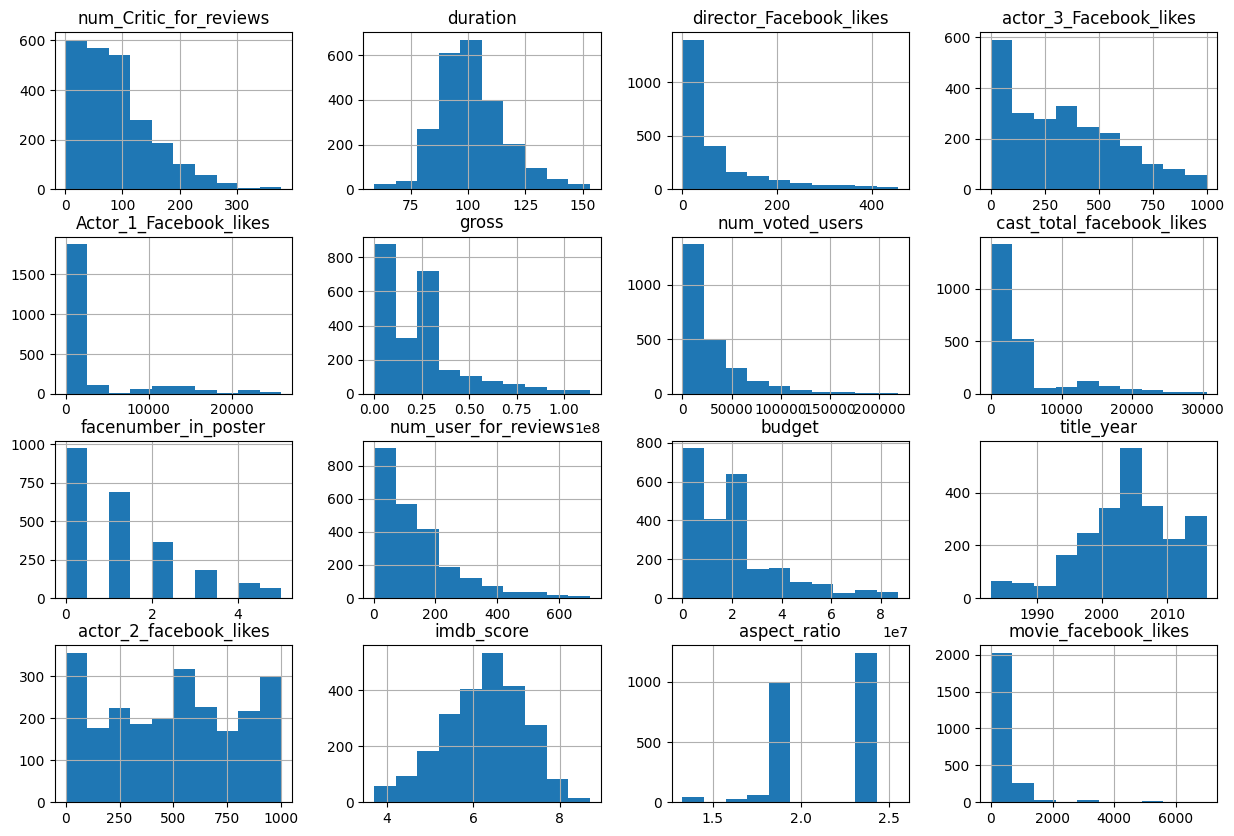

In [156]:
data_filtered.hist(figsize=(15, 10))